In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
import pandas as pd

# Standardize paths
path_ambient = "/content/drive/MyDrive/ProbStat/data/Preprocessed_Ambient"
path_music = "/content/drive/MyDrive/ProbStat/data/Preprocessed_Music"
path_jazz = "/content/drive/MyDrive/ProbStat/data/Preprocessed_Jazz"

# Get names of the files
ambient = [os.path.join(path_ambient, f) for f in os.listdir(path_ambient) if f.endswith(('.mp3', '.wav'))]
music = [os.path.join(path_music, f) for f in os.listdir(path_music) if f.endswith(('.mp3', '.wav'))]
jazz = [os.path.join(path_jazz, f) for f in os.listdir(path_jazz) if f.endswith(('.mp3', '.wav'))]
print(f"Found {len(ambient)} ambient files, {len(music)} music files and {len(jazz)} jazz files.")

# Load a subset of amplitudes to calculate a representative Bin Width
all_amplitudes = []
for fpath in (ambient + music + jazz):
    y, sr = librosa.load(fpath, sr=16000)
    all_amplitudes.extend(y)

all_amplitudes = np.array(all_amplitudes)

# Calculate Freedman-Diaconis Bin Width on the AMPLITUDE distribution
n = len(all_amplitudes)
q75, q25 = np.percentile(all_amplitudes, q=[75, 25])
iqr = q75 - q25
bin_width = (2 * iqr) / (n**(1/3)) if iqr > 0 else 0.01
print(f"New Amplitude-based Bin Width: {bin_width}")

# Calculate bins based on amplitude range [-1, 1]
bins = np.arange(-1, 1 + bin_width, bin_width)

Found 10 ambient files, 10 music files and 10 jazz files.
New Amplitude-based Bin Width: 0.0027878230979442144


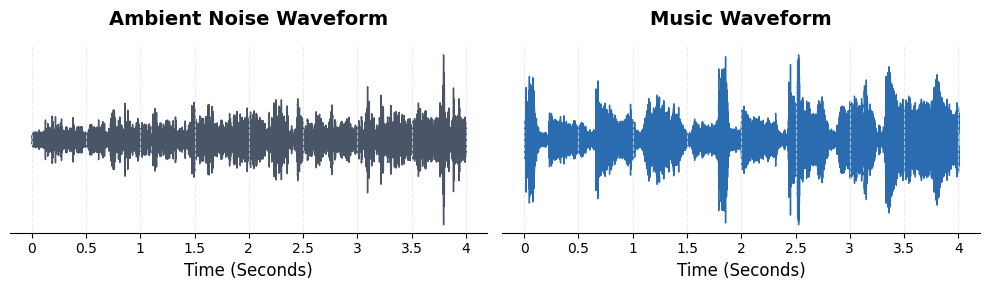

In [3]:
sample_rate = 16000

# Load the audio arrays
y_ambient, _ = librosa.load(ambient[0], sr=sample_rate)
y_music, _ = librosa.load(music[0], sr=sample_rate)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

# Plot Ambient Waveform
librosa.display.waveshow(y_ambient, sr=sample_rate, ax=axes[0], color="#4A5568") # Dark slate
axes[0].set_title("Ambient Noise Waveform", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Time (Seconds)", fontsize=12)

# Plot Music Waveform
librosa.display.waveshow(y_music, sr=sample_rate, ax=axes[1], color="#2B6CB0") # Deep blue
axes[1].set_title("Music Waveform", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Time (Seconds)", fontsize=12)

for ax in axes:
    # Set y-axis limits to keep waveforms uniform (-1 to 1 is standard for normalized audio)
    ax.set_ylim(-1.1, 1.1)

    # Remove top, right, and left borders for a minimalist look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Hide the y-axis ticks and labels (shape matters more than exact amplitude here)
    ax.set_yticks([])
    ax.set_ylabel("") # Remove librosa's default ylabel

    # Add a light gray background grid for the x-axis to ground the time scale
    ax.grid(axis='x', color='#E2E8F0', linestyle='--', alpha=0.7)

# Adjust layout to prevent titles or labels from getting cut off
plt.tight_layout()

# Save as a high-resolution PNG with a transparent background for your poster
plt.savefig("waveform_comparison.png", dpi=300, transparent=True)

# Display the plot
plt.show()

In [6]:
from scipy.stats import norm
# Function to plot histogram and Gaussian overlay
def plot_density_histogram(ax, data, color, title):
    # Plot the normalized histogram (density=True is crucial here!)
    ax.hist(data, bins=bins, density=True, color=color, alpha=0.75, label='Audio Amplitude')

    # Fit a theoretical Gaussian (Normal) distribution to the data
    mu, std = norm.fit(data)

    # Generate the x and y values for the ideal bell curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    # Plot the theoretical Gaussian as a bold, dashed line
    ax.plot(x, p, 'k--', linewidth=2, label=f'Ideal Gaussian\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Amplitude", fontsize=12)
    ax.legend(loc='upper right', frameon=False)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1167/3947708191.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x, p, 'k--', linewidth=2, label=f'Ideal Gaussian\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')
/tmp/ipykernel_1167/3947708191.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x, p, 'k--', linewidth=2, label=f'Ideal Gaussian\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')


In [7]:
print("Loading and concatenating all ambient files...")
y_ambient_all = np.concatenate([librosa.load(f, sr=sample_rate)[0] for f in ambient])

print("Loading and concatenating all music files...")
y_music_all = np.concatenate([librosa.load(f, sr=sample_rate)[0] for f in music])

Loading and concatenating all ambient files...
Loading and concatenating all music files...


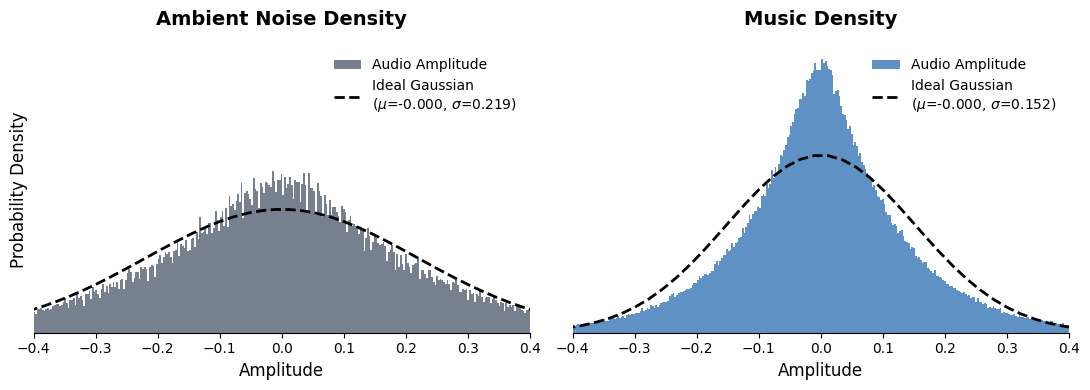

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

plot_density_histogram(axes[0], y_ambient_all, "#4A5568", "Ambient Noise Density")
plot_density_histogram(axes[1], y_music_all, "#2B6CB0", "Music Density")

for ax in axes:
    # Zoom in on the center where the mass is concentrated to see the shape clearly
    # (Adjust these limits if your data spreads further)
    ax.set_xlim(-0.4, 0.4)

    # Remove borders for a minimalist look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Keep the y-axis ticks for the first plot, hide for the second
    if ax == axes[1]:
        ax.set_yticks([])
    else:
        ax.set_ylabel("Probability Density", fontsize=12)
        # Lighten the y-axis ticks
        ax.tick_params(axis='y', colors='#4A5568')

    ax.grid(axis='y', color='#E2E8F0', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save for the poster!
plt.savefig("amplitude_density_histogram.png", dpi=300, transparent=True)
plt.show()

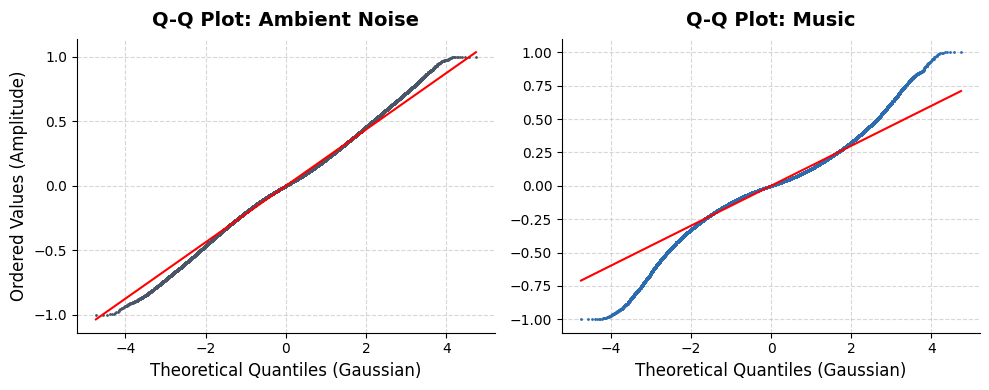

In [9]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ==========================================
# 1. Q-Q Plot for Ambient Noise
# ==========================================
# stats.probplot automatically calculates quantiles against a Normal distribution
stats.probplot(y_ambient_all, dist="norm", plot=axes[0])
axes[0].get_lines()[0].set_marker('.')
axes[0].get_lines()[0].set_color('#4A5568') # Match your Ambient color
axes[0].get_lines()[0].set_markersize(2)
axes[0].get_lines()[1].set_color('red') # The ideal straight line

axes[0].set_title("Q-Q Plot: Ambient Noise", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Theoretical Quantiles (Gaussian)", fontsize=12)
axes[0].set_ylabel("Ordered Values (Amplitude)", fontsize=12)

# ==========================================
# 2. Q-Q Plot for Music
# ==========================================
stats.probplot(y_music_all, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_marker('.')
axes[1].get_lines()[0].set_color('#2B6CB0') # Match your Music color
axes[1].get_lines()[0].set_markersize(2)
axes[1].get_lines()[1].set_color('red')

axes[1].set_title("Q-Q Plot: Music", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Theoretical Quantiles (Gaussian)", fontsize=12)
axes[1].set_ylabel("") # Hide y-label for cleaner look

# ==========================================
# 3. Clean Formatting
# ==========================================
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("qq_plot_comparison.png", dpi=300, transparent=True)
plt.show()

/tmp/ipykernel_1167/2358555337.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1167/2358555337.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


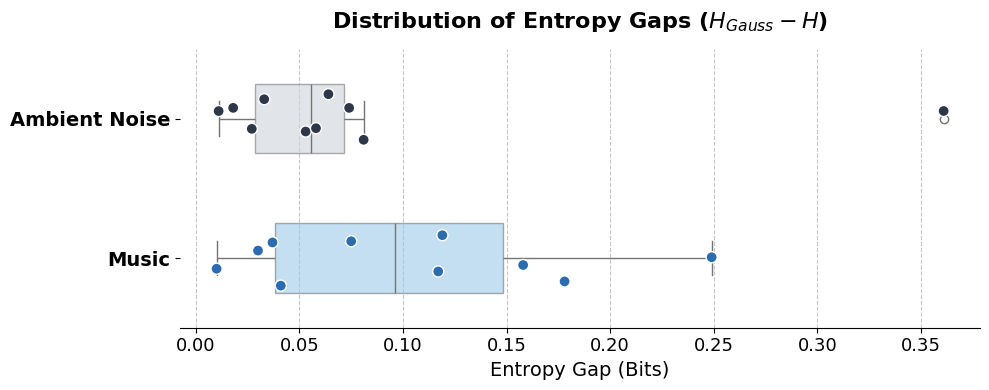

In [12]:
import seaborn as sns

# Data
ambient_gaps = [
    0.053, 0.011, 0.064, 0.081, 0.033, 0.027, 0.058, 0.361, 0.018, 0.074
]

music_gaps = [
    0.119, 0.037, 0.030, 0.041, 0.075, 0.249, 0.178, 0.117, 0.010, 0.158
]


# Create DataFrame
df = pd.DataFrame({
    'Audio Type': ['Ambient Noise'] * len(ambient_gaps) + ['Music'] * len(music_gaps),
    'Entropy Gap': ambient_gaps + music_gaps
})

fig, ax = plt.subplots(figsize=(10, 4))

# Draw the horizontal boxplot (lightly colored)
sns.boxplot(
    x='Entropy Gap',
    y='Audio Type',
    data=df,
    palette=['#CBD5E0', '#90CDF4'], # Light slate and light blue backgrounds
    width=0.5,
    boxprops=dict(alpha=0.6), # Make boxes slightly transparent
    ax=ax
)

# Overlay the individual data points (the "strip plot") to act like a histogram
sns.stripplot(
    x='Entropy Gap',
    y='Audio Type',
    data=df,
    palette=['#2D3748', '#2B6CB0'], # Dark slate and deep blue dots
    size=8, # Make dots large enough to see from a distance
    jitter=0.2, # Spreads out dots that have the exact same value (like the 0.000s)
    linewidth=1,
    edgecolor='white',
    ax=ax
)

ax.set_title("Distribution of Entropy Gaps ($H_{Gauss} - H$)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Entropy Gap (Bits)", fontsize=14)
ax.set_ylabel("") # Hide y-label since "Ambient" and "Music" are obvious

plt.xticks(fontsize=13)
plt.yticks(fontsize=14, fontweight='bold')

# Remove top, right, and left borders for a sleek look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add vertical grid lines to easily read the horizontal values
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()

# Save as a wide, transparent image for the poster
plt.savefig("horizontal_entropy_distribution.png", dpi=300, transparent=True)
plt.show()

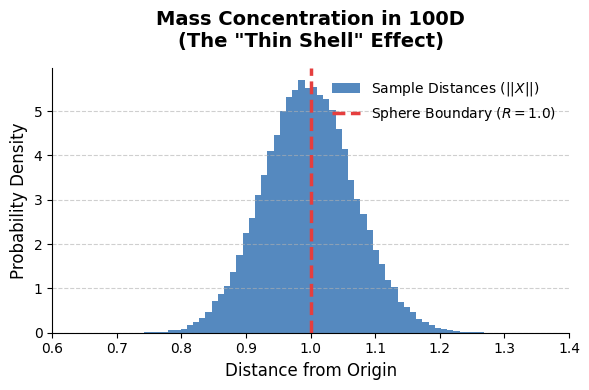

In [10]:

# 1. Simulate the Gaussian Proposal in 100D
# ==========================================
n = 100      # 100 Dimensions
R = 1.0      # Unit sphere radius
sigma = R / np.sqrt(n)  # Your calibrated step size

# Generate 50,000 samples from your proposal distribution
samples = np.random.normal(0, sigma, (50000, n))

# Calculate the distance of each sample from the origin (Euclidean norm)
distances = np.linalg.norm(samples, axis=1)

# ==========================================
# 2. Setup the Poster-Ready Figure
# ==========================================
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the density of where the samples actually landed
ax.hist(distances, bins=60, density=True, color='#2B6CB0', alpha=0.8, label='Sample Distances ($||X||$)')

# Draw a bold line exactly where the boundary of the sphere is
ax.axvline(R, color='#E53E3E', linestyle='--', linewidth=2.5, label=f'Sphere Boundary ($R={R}$)')

# ==========================================
# 3. Clean Formatting
# ==========================================
ax.set_title("Mass Concentration in 100D\n(The \"Thin Shell\" Effect)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Distance from Origin", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)

# Zoom in on the relevant area to show how tight the clustering is
ax.set_xlim(0.6, 1.4)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("thin_shell_concentration.png", dpi=300, transparent=True)
plt.show()